In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [4]:
data = pd.read_csv("../../data/try_scorer.csv")
data.head(2)

,players,try_match,match_played,tries,team
0,Bielle-Biarrey,1.33,3,4,France
1,Arundell,1.33,3,4,Angleterre


In [5]:
df = data.copy()

In [6]:
print(plt.style.available)
plt.style.use('seaborn-v0_8-pastel')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


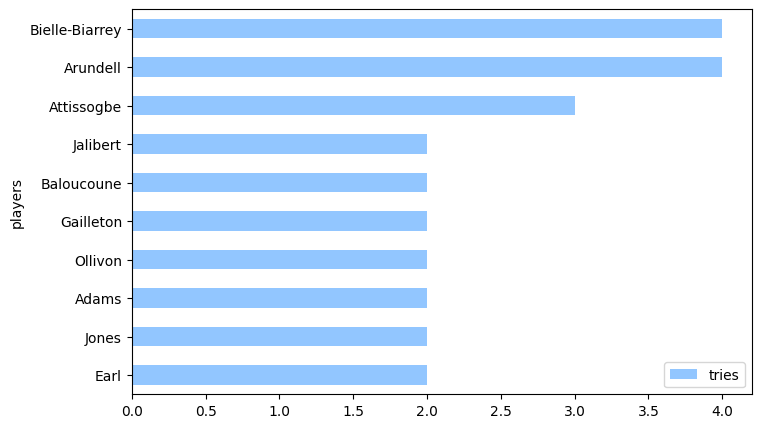

In [7]:
top_scorers = df.sort_values("tries", ascending=False).head(10)

top_scorers.plot(
    kind="barh",
    x="players",
    y="tries",
    figsize=(8,5)
)
plt.gca().invert_yaxis()

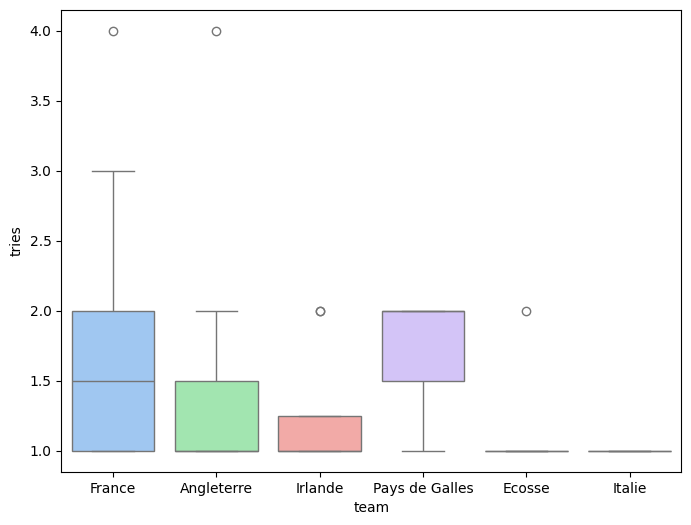

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="team", y="tries", hue = "team")
plt.show()

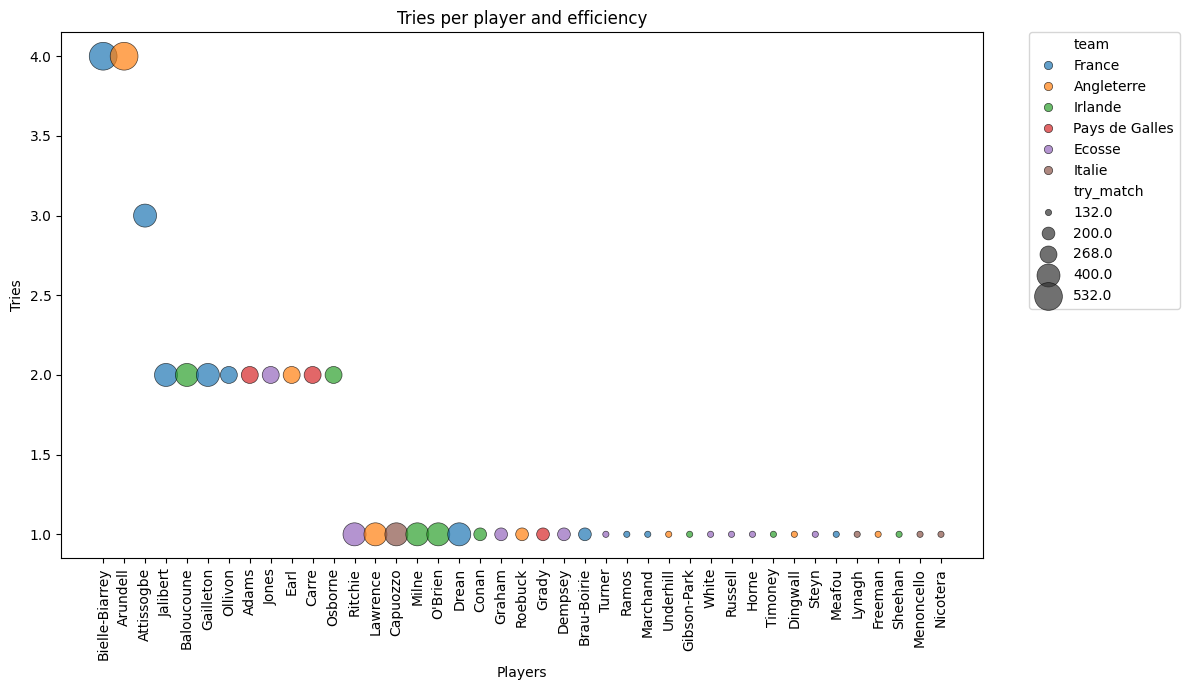

In [9]:
plt.figure(figsize=(12,7))

# Bubble size based on efficiency (tries per match)
sizes = df["try_match"] * 400  #  multiply to make bubble sizes clearly visible

sns.scatterplot(
    data=df,
    x="players",
    y="tries",
    hue="team",          # color by team
    size=sizes,          # variable bubble size
    sizes=(20, 400),     # size range limits
    palette="tab10",
    alpha=0.7,
    edgecolor="black",   # outline for better readability
    linewidth=0.5
)

plt.xticks(rotation=90)
plt.xlabel("Players")
plt.ylabel("Tries")
plt.title("Tries per player and efficiency")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

In [10]:
df_team = df.groupby(["team"])["tries"].sum().reset_index()
df_team = df_team.sort_values("tries", ascending = False )

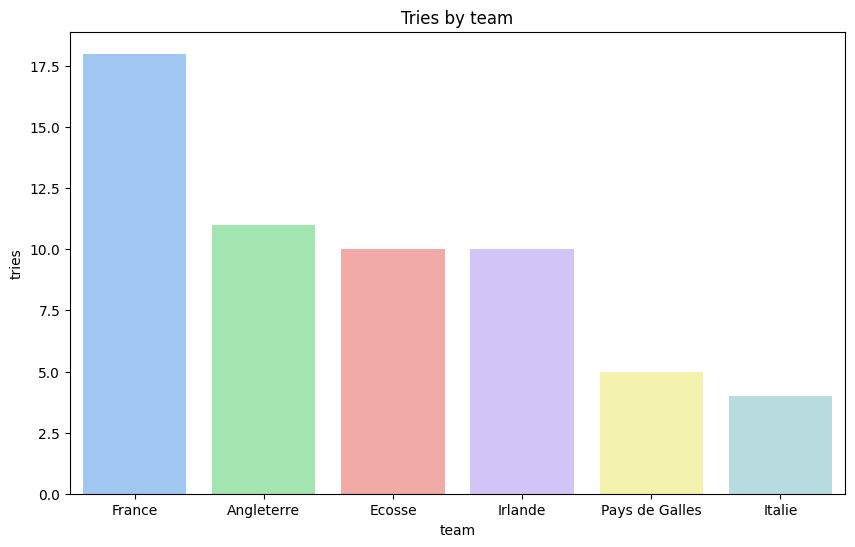

In [11]:
plt.figure(figsize =(10,6))
sns.barplot(data = df_team, x = "team",y = "tries", hue = "team")
plt.title("Tries by team")
plt.show()

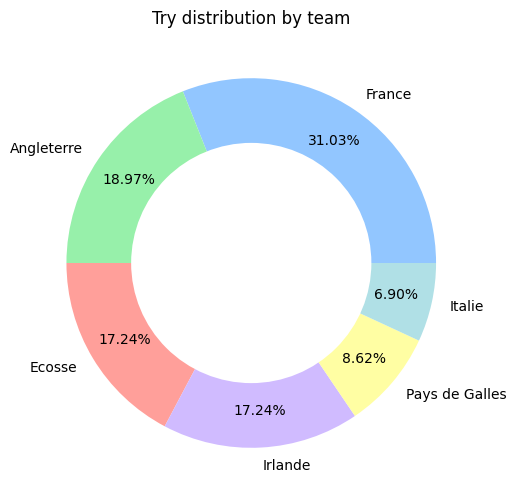

In [12]:
plt.figure(figsize =(6,6))
plt.pie(df_team["tries"], labels = df_team["team"], autopct="%1.2f%%", pctdistance=0.80 )

# draw circle
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
fig = plt.gcf()

# adding circle in pie chart
fig.gca().add_artist(centre_circle)

plt.title("Try distribution by team")
plt.show()

In [13]:
df_grouped = df.groupby(["players", "team"])["tries"].sum().reset_index()
df_grouped.head(2)

,players,team,tries
0,Adams,Pays de Galles,2
1,Arundell,Angleterre,4


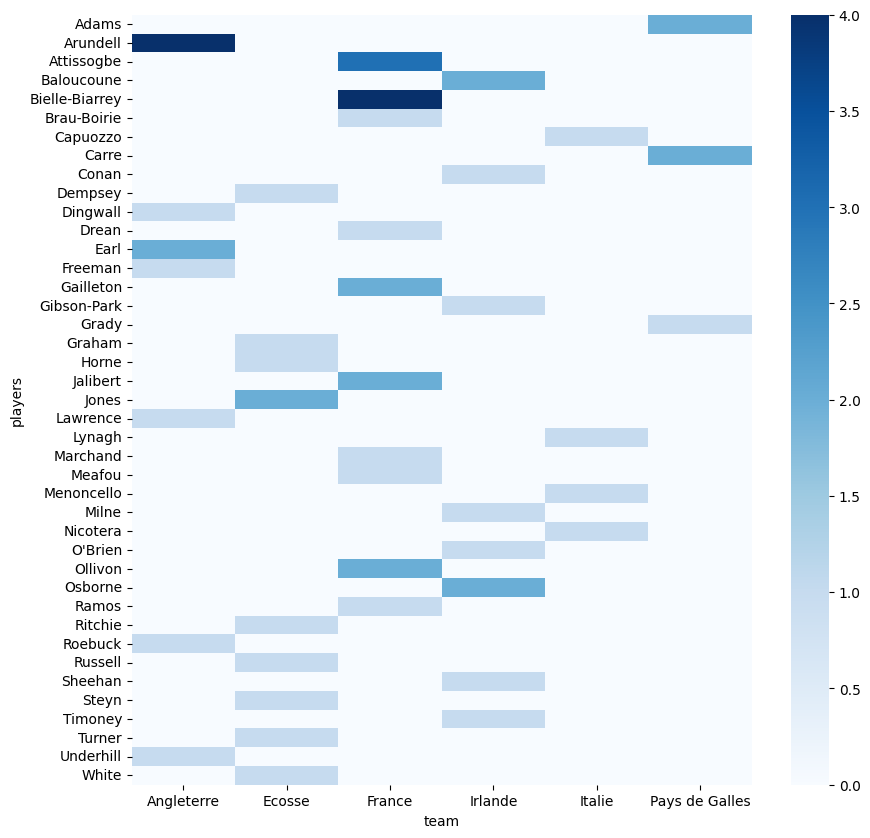

In [14]:
pivot = df_grouped.pivot_table(
    index="players",
    columns="team",
    values="tries"
).fillna(0)

plt.figure(figsize=(10, 10))
sns.heatmap(pivot, cmap="Blues")
plt.title("")
plt.show()

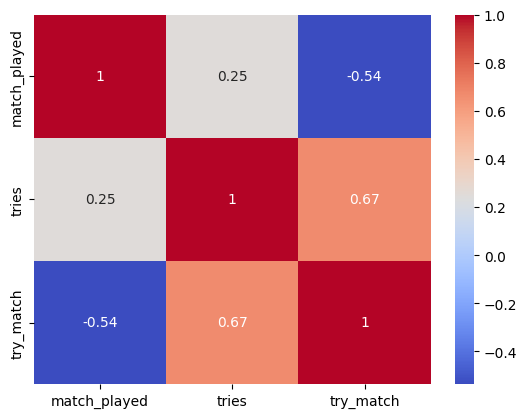

In [15]:
sns.heatmap(df[["match_played","tries","try_match"]].corr(), 
            annot=True, cmap="coolwarm")
plt.show()